# Numerical Methods Final Exam

This notebook implements numerical differentiation, numerical integration, Euler's method, RK2 Heun's method, and RK4 using NumPy, Pandas, Matplotlib, and the Python standard library.


## AI Use Disclosure

I used ChatGPT/Codex for coding assistance, debugging support, notebook organization, and help preparing concise interpretations. I personally verified that the formulas, method implementations, tables, plots, and final numerical results match the exam requirements and can explain the code line by line.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 10)


## Part A. Numerical Differentiation with Error Acceleration

The test function is

\[
f(x)=e^{-x}\sin(2x)
\]

with exact derivative

\[
f'(x)=e^{-x}(2\cos(2x)-\sin(2x)).
\]


In [2]:
def f_diff(x):
    return np.exp(-x) * np.sin(2 * x)


def exact_derivative(x):
    return np.exp(-x) * (2 * np.cos(2 * x) - np.sin(2 * x))


def forward_difference(f, x0, h):
    return (f(x0 + h) - f(x0)) / h


def backward_difference(f, x0, h):
    return (f(x0) - f(x0 - h)) / h


def central_difference(f, x0, h):
    return (f(x0 + h) - f(x0 - h)) / (2 * h)


def richardson_central_difference(f, x0, h):
    return (4 * central_difference(f, x0, h / 2) - central_difference(f, x0, h)) / 3


x0 = 1.0
h_values = np.array([0.4, 0.2, 0.1, 0.05, 0.025])
exact_fp = exact_derivative(x0)

rows = []
previous_errors = None
for h in h_values:
    approximations = {
        "Forward": forward_difference(f_diff, x0, h),
        "Backward": backward_difference(f_diff, x0, h),
        "Central": central_difference(f_diff, x0, h),
        "Richardson Central": richardson_central_difference(f_diff, x0, h),
    }
    errors = {name: abs(value - exact_fp) for name, value in approximations.items()}
    ratios = {
        name: np.nan if previous_errors is None else previous_errors[name] / errors[name]
        for name in approximations
    }
    rows.append(
        {
            "h": h,
            **{f"{name} Approx": value for name, value in approximations.items()},
            "Exact f'(1)": exact_fp,
            **{f"{name} Abs Error": error for name, error in errors.items()},
            **{f"{name} Error Ratio": ratio for name, ratio in ratios.items()},
        }
    )
    previous_errors = errors

diff_table = pd.DataFrame(rows)
diff_table


,h,Forward Approx,Backward Approx,Central Approx,Richardson Central Approx,Exact f'(1),Forward Abs Error,Backward Abs Error,Central Abs Error,Richardson Central Abs Error,Forward Error Ratio,Backward Error Ratio,Central Error Ratio,Richardson Central Error Ratio
0,0.400,-0.6297619211,-0.4425051661,-0.5361335436,-0.6402613897,-0.6406955606,0.0109336395,0.1981903945,0.1045620170,0.0004341709,NaN,NaN,NaN,NaN
1,0.200,-0.6553311445,-0.5731277119,-0.6142294282,-0.6406690294,-0.6406955606,0.0146355839,0.0675678487,0.0264661324,0.0000265312,0.7470586433,2.9332056336,3.9507856820,16.3645515135
2,0.100,-0.6538675513,-0.6142507069,-0.6340591291,-0.6406939120,-0.6406955606,0.0131719908,0.0264448537,0.0066364315,0.0000016485,1.1111140432,2.5550471715,3.9880065748,16.0936760668
3,0.050,-0.6488457292,-0.6292247034,-0.6390352163,-0.6406954577,-0.6406955606,0.0081501687,0.0114708572,0.0016603443,0.0000001029,1.6161617381,2.3053947237,3.9970213160,16.0235793969
4,0.025,-0.6451739136,-0.6353868811,-0.6402803974,-0.6406955542,-0.6406955606,0.0044783530,0.0053086795,0.0004151632,0.0000000064,1.8199031400,2.1607741307,3.9992565630,16.0058980011


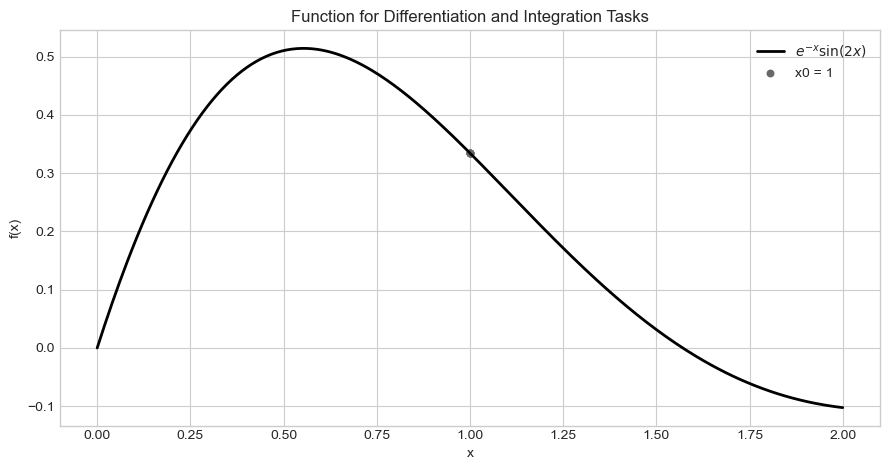

In [3]:
x_plot = np.linspace(0, 2, 300)
plt.figure(figsize=(9, 4.8))
plt.plot(x_plot, f_diff(x_plot), color="black", linewidth=2, label=r"$e^{-x}\sin(2x)$")
plt.scatter(h_values * 0 + x0, [f_diff(x0)] * len(h_values), s=22, color="dimgray", label="x0 = 1")
plt.title("Function for Differentiation and Integration Tasks")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()


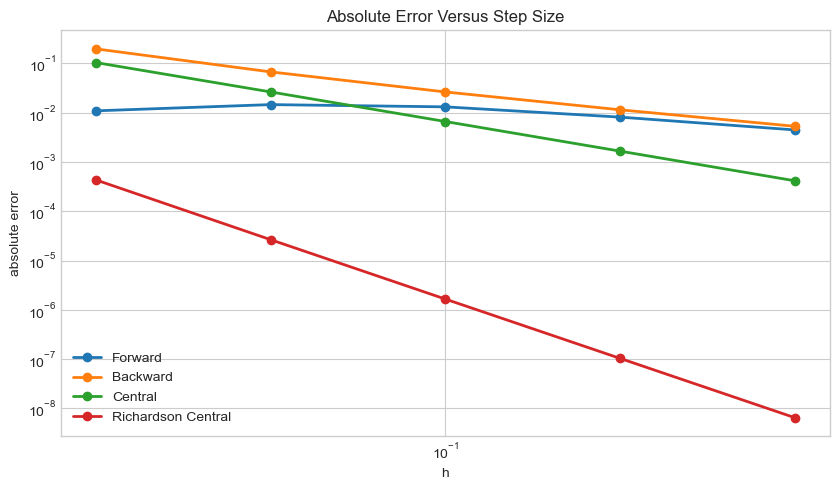

In [4]:
error_columns = [
    "Forward Abs Error",
    "Backward Abs Error",
    "Central Abs Error",
    "Richardson Central Abs Error",
]

plt.figure(figsize=(8.5, 5))
for col in error_columns:
    plt.loglog(diff_table["h"], diff_table[col], marker="o", linewidth=2, label=col.replace(" Abs Error", ""))
plt.gca().invert_xaxis()
plt.title("Absolute Error Versus Step Size")
plt.xlabel("h")
plt.ylabel("absolute error")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
order_rows = []
for col in error_columns:
    method = col.replace(" Abs Error", "")
    errors = diff_table[col].to_numpy()
    observed_orders = np.log(errors[:-1] / errors[1:]) / np.log(h_values[:-1] / h_values[1:])
    order_rows.append(
        {
            "Method": method,
            "Mean observed order": np.mean(observed_orders),
            "Last observed order": observed_orders[-1],
        }
    )
order_table = pd.DataFrame(order_rows)
order_table


,Method,Mean observed order,Last observed order
0,Forward,0.3219333888,0.8638616685
1,Backward,1.3055975503,1.1115482728
2,Central,1.9941161196,1.9997318369
3,Richardson Central,4.0108951054,4.0005317156


**Interpretation.** Forward and backward differences are first-order methods, so halving \(h\) reduces their error by about a factor of 2. The central difference is second order, so its error ratio is close to 4 when \(h\) is halved. Richardson extrapolation cancels the leading central-difference error term, producing a much faster fourth-order trend. The log-log plot confirms the ranking: Richardson-enhanced central difference is most accurate, followed by central difference, then forward/backward difference.


## Part B. Numerical Integration

Approximate

\[
I=\int_0^2 \ln(1+x^2)\,dx
\]

using composite trapezoidal, composite Simpson's 1/3, and composite two-point Gauss-Legendre quadrature. The exact value is

\[
I_{exact}=2\ln(5)-4+2\arctan(2).
\]


In [6]:
def g_integrand(x):
    return np.log(1 + x**2)


def composite_trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])


def composite_simpson_13(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("Composite Simpson's 1/3 rule requires an even n.")
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h / 3 * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum())


def composite_gauss_legendre_2(f, a, b, n):
    h = (b - a) / n
    nodes = np.array([-1 / math.sqrt(3), 1 / math.sqrt(3)])
    total = 0.0
    for i in range(n):
        left = a + i * h
        right = left + h
        midpoint = (left + right) / 2
        half_width = (right - left) / 2
        total += half_width * np.sum(f(midpoint + half_width * nodes))
    return total


a, b = 0.0, 2.0
n_values = [4, 8, 16, 32, 64]
exact_integral = 2 * math.log(5) - 4 + 2 * math.atan(2)

integration_rows = []
for n in n_values:
    estimates = {
        "Trapezoidal": composite_trapezoidal(g_integrand, a, b, n),
        "Simpson 1/3": composite_simpson_13(g_integrand, a, b, n),
        "Gauss-Legendre 2": composite_gauss_legendre_2(g_integrand, a, b, n),
    }
    errors = {name: abs(value - exact_integral) for name, value in estimates.items()}
    best_method = min(errors, key=errors.get)
    integration_rows.append(
        {
            "n": n,
            **{f"{name} Estimate": value for name, value in estimates.items()},
            "Exact Value": exact_integral,
            **{f"{name} Abs Error": error for name, error in errors.items()},
            "Best Method": best_method,
        }
    )

integration_table = pd.DataFrame(integration_rows)
integration_table


,n,Trapezoidal Estimate,Simpson 1/3 Estimate,Gauss-Legendre 2 Estimate,Exact Value,Trapezoidal Abs Error,Simpson 1/3 Abs Error,Gauss-Legendre 2 Abs Error,Best Method
0,4,1.4498323422,1.4338210774,1.4331718517,1.4331732605,0.0166590818,0.0006478169,1.4087477587e-06,Gauss-Legendre 2
1,8,1.4373395752,1.4331753196,1.4331732016,1.4331732605,0.0041663148,0.0000020591,5.8903161682e-08,Gauss-Legendre 2
2,16,1.4342149053,1.4331733487,1.4331732568,1.4331732605,0.0010416449,0.0000000883,3.6332004072e-09,Gauss-Legendre 2
3,32,1.4334336758,1.4331732659,1.4331732602,1.4331732605,0.0002604153,0.0000000054,2.2631119201e-10,Gauss-Legendre 2
4,64,1.4332383645,1.4331732608,1.4331732604,1.4331732605,0.0000651041,0.0000000003,1.4132250925e-11,Gauss-Legendre 2


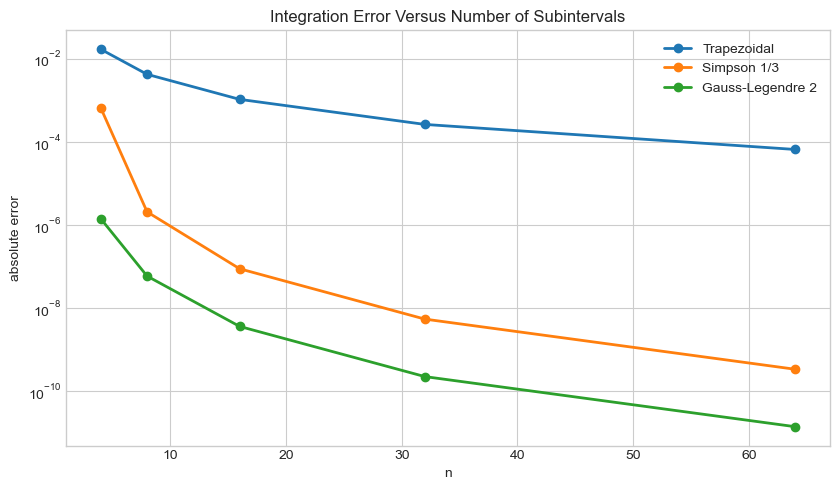

In [7]:
plt.figure(figsize=(8.5, 5))
for method in ["Trapezoidal", "Simpson 1/3", "Gauss-Legendre 2"]:
    plt.semilogy(
        integration_table["n"],
        integration_table[f"{method} Abs Error"],
        marker="o",
        linewidth=2,
        label=method,
    )
plt.title("Integration Error Versus Number of Subintervals")
plt.xlabel("n")
plt.ylabel("absolute error")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Increasing \(n\) makes the subinterval width smaller, so all three integration methods converge toward the exact integral. The trapezoidal rule improves steadily but is the least accurate because it is second order. Simpson's 1/3 rule is fourth order, so its error drops much faster. The two-point Gauss-Legendre rule is also very accurate on each subinterval and gives the smallest or near-smallest error for these values of \(n\).


## Part C. ODE by Euler and RK2 with Step-Size Sensitivity

Solve

\[
y'=y-t^2+1,\quad y(0)=0.5
\]

on \(0\le t\le 2\). The exact solution is

\[
y(t)=(t+1)^2-0.5e^t.
\]


In [8]:
def ode_rhs(t, y):
    return y - t**2 + 1


def exact_solution(t):
    return (t + 1) ** 2 - 0.5 * np.exp(t)


def euler_method(f, t0, y0, h, t_end):
    t_values = np.arange(t0, t_end + h / 2, h)
    y_values = np.zeros_like(t_values, dtype=float)
    y_values[0] = y0
    for i in range(len(t_values) - 1):
        y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])
    return t_values, y_values


def rk2_heun_method(f, t0, y0, h, t_end):
    t_values = np.arange(t0, t_end + h / 2, h)
    y_values = np.zeros_like(t_values, dtype=float)
    y_values[0] = y0
    for i in range(len(t_values) - 1):
        k1 = f(t_values[i], y_values[i])
        k2 = f(t_values[i] + h, y_values[i] + h * k1)
        y_values[i + 1] = y_values[i] + h * (k1 + k2) / 2
    return t_values, y_values


h_ode_values = [0.4, 0.2, 0.1]
ode_rows = []
for h in h_ode_values:
    _, y_euler = euler_method(ode_rhs, 0.0, 0.5, h, 2.0)
    _, y_rk2 = rk2_heun_method(ode_rhs, 0.0, 0.5, h, 2.0)
    exact_final = exact_solution(2.0)
    ode_rows.append(
        {
            "h": h,
            "Euler y(2)": y_euler[-1],
            "RK2 y(2)": y_rk2[-1],
            "Exact y(2)": exact_final,
            "Euler Abs Error": abs(y_euler[-1] - exact_final),
            "RK2 Abs Error": abs(y_rk2[-1] - exact_final),
        }
    )

ode_table = pd.DataFrame(ode_rows)
ode_table


,h,Euler y(2),RK2 y(2),Exact y(2),Euler Abs Error,RK2 Abs Error
0,0.4,4.5595840000,5.0428679885,5.3054719505,0.7458879505,0.2626039621
1,0.2,4.8657845043,5.2330546302,5.3054719505,0.4396874462,0.0724173203
2,0.1,5.0635000304,5.2865671750,5.3054719505,0.2419719201,0.0189047755


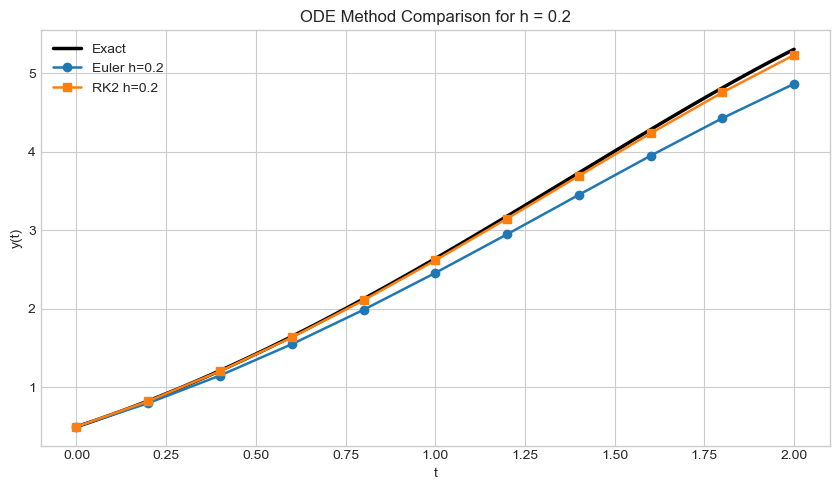

In [9]:
h = 0.2
t_euler, y_euler = euler_method(ode_rhs, 0.0, 0.5, h, 2.0)
t_rk2, y_rk2 = rk2_heun_method(ode_rhs, 0.0, 0.5, h, 2.0)
t_exact = np.linspace(0, 2, 300)

plt.figure(figsize=(8.5, 5))
plt.plot(t_exact, exact_solution(t_exact), color="black", linewidth=2.5, label="Exact")
plt.plot(t_euler, y_euler, marker="o", linewidth=1.8, label="Euler h=0.2")
plt.plot(t_rk2, y_rk2, marker="s", linewidth=1.8, label="RK2 h=0.2")
plt.title("ODE Method Comparison for h = 0.2")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.tight_layout()
plt.show()


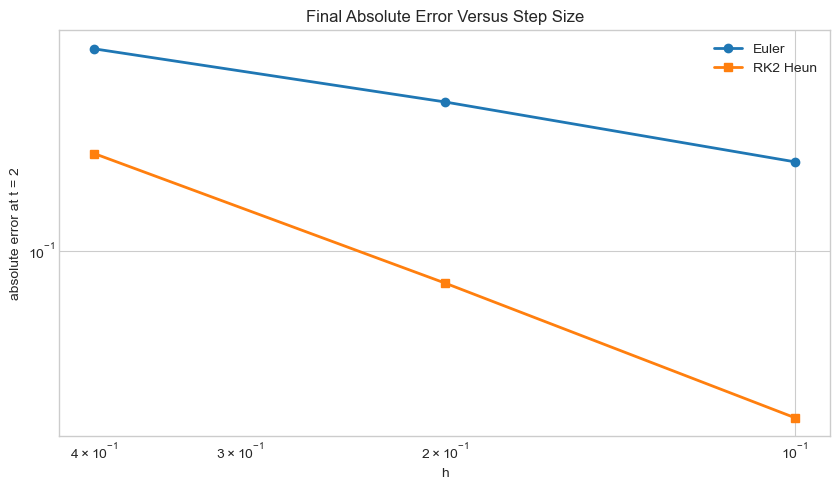

In [10]:
plt.figure(figsize=(8.5, 5))
plt.loglog(ode_table["h"], ode_table["Euler Abs Error"], marker="o", linewidth=2, label="Euler")
plt.loglog(ode_table["h"], ode_table["RK2 Abs Error"], marker="s", linewidth=2, label="RK2 Heun")
plt.gca().invert_xaxis()
plt.title("Final Absolute Error Versus Step Size")
plt.xlabel("h")
plt.ylabel("absolute error at t = 2")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Smaller step sizes improve accuracy because the numerical path is updated more often. The tradeoff is computational cost: halving \(h\) roughly doubles the number of steps and function evaluations. Euler is cheaper per step but much less accurate, while RK2 uses two function evaluations per step and usually achieves a better accuracy-to-cost balance.


## Part D. ODE by RK4 and Method Comparison

The same IVP is solved using the classical fourth-order Runge-Kutta method and compared with Euler, RK2, and the exact solution.


In [11]:
def rk4_method(f, t0, y0, h, t_end):
    t_values = np.arange(t0, t_end + h / 2, h)
    y_values = np.zeros_like(t_values, dtype=float)
    y_values[0] = y0
    for i in range(len(t_values) - 1):
        t_i = t_values[i]
        y_i = y_values[i]
        k1 = f(t_i, y_i)
        k2 = f(t_i + h / 2, y_i + h * k1 / 2)
        k3 = f(t_i + h / 2, y_i + h * k2 / 2)
        k4 = f(t_i + h, y_i + h * k3)
        y_values[i + 1] = y_i + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t_values, y_values


comparison_rows = []
for h in [0.2, 0.1]:
    _, y_euler = euler_method(ode_rhs, 0.0, 0.5, h, 2.0)
    _, y_rk2 = rk2_heun_method(ode_rhs, 0.0, 0.5, h, 2.0)
    _, y_rk4 = rk4_method(ode_rhs, 0.0, 0.5, h, 2.0)
    exact_final = exact_solution(2.0)
    comparison_rows.extend(
        [
            {
                "h": h,
                "Method": "Euler",
                "Final y(2)": y_euler[-1],
                "Exact y(2)": exact_final,
                "Absolute Error": abs(y_euler[-1] - exact_final),
                "Function evaluations per step": 1,
            },
            {
                "h": h,
                "Method": "RK2 Heun",
                "Final y(2)": y_rk2[-1],
                "Exact y(2)": exact_final,
                "Absolute Error": abs(y_rk2[-1] - exact_final),
                "Function evaluations per step": 2,
            },
            {
                "h": h,
                "Method": "RK4",
                "Final y(2)": y_rk4[-1],
                "Exact y(2)": exact_final,
                "Absolute Error": abs(y_rk4[-1] - exact_final),
                "Function evaluations per step": 4,
            },
        ]
    )

final_comparison_table = pd.DataFrame(comparison_rows)
final_comparison_table


,h,Method,Final y(2),Exact y(2),Absolute Error,Function evaluations per step
0,0.2,Euler,4.8657845043,5.3054719505,0.4396874462,1
1,0.2,RK2 Heun,5.2330546302,5.3054719505,0.0724173203,2
2,0.2,RK4,5.3053630007,5.3054719505,0.0001089498,4
3,0.1,Euler,5.0635000304,5.3054719505,0.2419719201,1
4,0.1,RK2 Heun,5.2865671750,5.3054719505,0.0189047755,2
5,0.1,RK4,5.3054649602,5.3054719505,0.0000069903,4


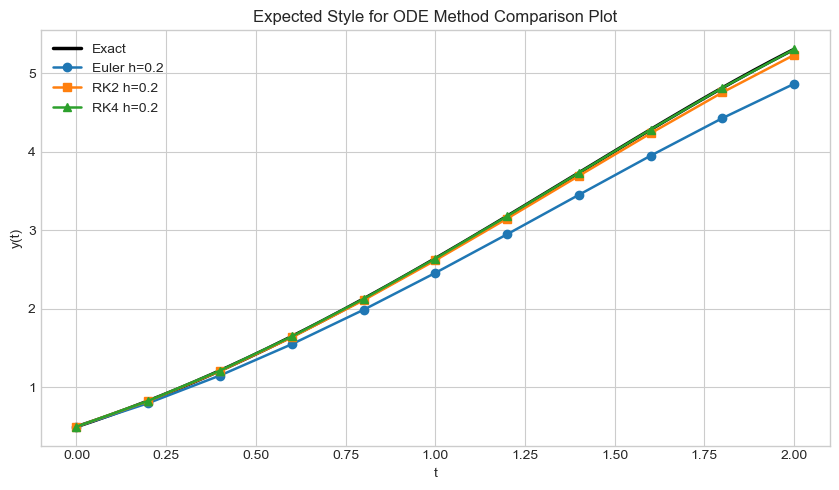

In [12]:
h = 0.2
t_euler, y_euler = euler_method(ode_rhs, 0.0, 0.5, h, 2.0)
t_rk2, y_rk2 = rk2_heun_method(ode_rhs, 0.0, 0.5, h, 2.0)
t_rk4, y_rk4 = rk4_method(ode_rhs, 0.0, 0.5, h, 2.0)
t_exact = np.linspace(0, 2, 300)

plt.figure(figsize=(8.5, 5))
plt.plot(t_exact, exact_solution(t_exact), color="black", linewidth=2.5, label="Exact")
plt.plot(t_euler, y_euler, marker="o", linewidth=1.8, label="Euler h=0.2")
plt.plot(t_rk2, y_rk2, marker="s", linewidth=1.8, label="RK2 h=0.2")
plt.plot(t_rk4, y_rk4, marker="^", linewidth=1.8, label="RK4 h=0.2")
plt.title("Expected Style for ODE Method Comparison Plot")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.tight_layout()
plt.show()


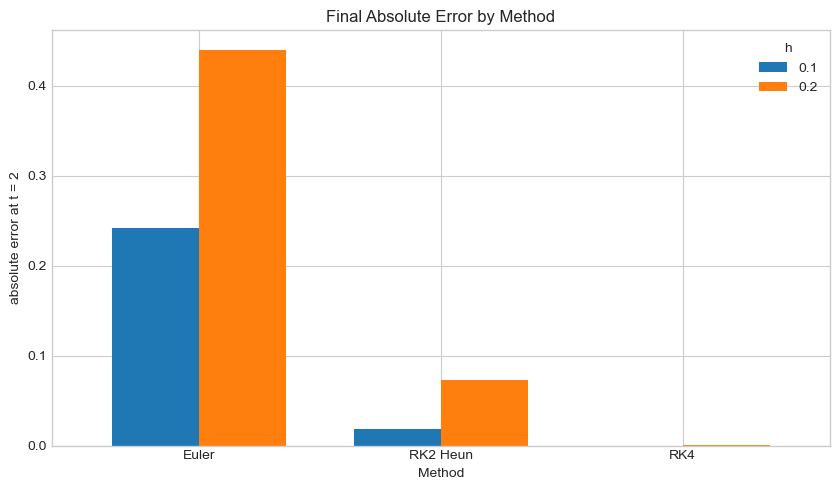

In [13]:
bar_source = final_comparison_table.pivot(index="Method", columns="h", values="Absolute Error")
ax = bar_source.plot(kind="bar", figsize=(8.5, 5), width=0.72)
ax.set_title("Final Absolute Error by Method")
ax.set_xlabel("Method")
ax.set_ylabel("absolute error at t = 2")
ax.legend(title="h")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Conclusion.** RK4 is the most accurate method, followed by RK2 Heun, then Euler. Euler uses only one function evaluation per step, RK2 uses two, and RK4 uses four. The extra RK4 cost is justified when high accuracy is required or when larger step sizes must still give reliable results; Euler is only attractive for rough estimates or very low-cost exploratory calculations.
